In [1]:
# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
# 2. Import configuration values

from config import (
    DATA_PATH,
    DATA_COLUMNS,
    TARGET_COLUMN,
    TEXT_COLUMN,
    SENTIMENT_COLUMN,
    SENTIMENT_LABELS,
    POSITIVE_LABEL,
    NEGATIVE_LABEL,
    SAMPLE_SIZE,
    RANDOM_STATE,
    WORDCLOUD_WIDTH,
    WORDCLOUD_HEIGHT,
    WORDCLOUD_BACKGROUND_COLOR,
    WORDCLOUD_MAX_WORDS,
    OUTPUT_DIR,
    WORDCLOUD_OUTPUT_PATH,
)

In [3]:
# 3. Check configuration values

print("W2M5 Personal Assignment: Sentiment Word Cloud")
print("-" * 50)
print(f"Data path: {DATA_PATH}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"WordCloud output path: {WORDCLOUD_OUTPUT_PATH}")
print(f"Target column: {TARGET_COLUMN}")
print(f"Text column: {TEXT_COLUMN}")
print(f"Sentiment column: {SENTIMENT_COLUMN}")
print(f"Sentiment labels: {SENTIMENT_LABELS}")
print(f"Sample size: {SAMPLE_SIZE}")
print(f"Random state: {RANDOM_STATE}")
print(f"WordCloud max words: {WORDCLOUD_MAX_WORDS}")

W2M5 Personal Assignment: Sentiment Word Cloud
--------------------------------------------------
Data path: /Users/admin/Documents/GitHub/HDST_8th/missions/W2/data/raw/training.1600000.processed.noemoticon.csv
Output dir: /Users/admin/Documents/GitHub/HDST_8th/missions/W2/W2M5/individual/output
WordCloud output path: /Users/admin/Documents/GitHub/HDST_8th/missions/W2/W2M5/individual/output/sentiment_wordcloud.png
Target column: target
Text column: text
Sentiment column: sentiment
Sentiment labels: {0: 'negative', 4: 'positive'}
Sample size: 1000
Random state: 42
WordCloud max words: 200


In [4]:
# 4. Load dataset

df = pd.read_csv(
    DATA_PATH,
    encoding="latin-1",
    header=None,
    names=DATA_COLUMNS,
)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

display(df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/Users/admin/Documents/GitHub/HDST_8th/missions/W2/data/raw/training.1600000.processed.noemoticon.csv'

In [ ]:
# 5. Check dataset information

print("Columns:")
print(df.columns.tolist())

print("\nTarget value counts:")
print(df[TARGET_COLUMN].value_counts())

print("\nMissing values:")
print(df[[TARGET_COLUMN, TEXT_COLUMN]].isnull().sum())

Columns:
['target', 'id', 'date', 'flag', 'user', 'text']

Target value counts:
target
0    800000
4    800000
Name: count, dtype: int64

Missing values:
target    0
text      0
dtype: int64


## Dataset Check

The dataset contains 1,600,000 tweets and 6 columns: target, id, date, flag, user, and text.

The target column has two sentiment labels:
- 0: negative sentiment
- 4: positive sentiment

The dataset is balanced, with 800,000 negative tweets and 800,000 positive tweets.
There are no missing values in the target and text columns.

In [ ]:
# 6. Map target values to sentiment labels

df[SENTIMENT_COLUMN] = df[TARGET_COLUMN].map(SENTIMENT_LABELS)

print("Sentiment label mapping completed.")
display(df[[TARGET_COLUMN, SENTIMENT_COLUMN, TEXT_COLUMN]].head())

print("\nSentiment value counts:")
print(df[SENTIMENT_COLUMN].value_counts())

Sentiment label mapping completed.


,target,sentiment,text
0,0,negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,negative,is upset that he can't update his Facebook by ...
2,0,negative,@Kenichan I dived many times for the ball. Man...
3,0,negative,my whole body feels itchy and like its on fire
4,0,negative,"@nationwideclass no, it's not behaving at all...."



Sentiment value counts:
sentiment
negative    800000
positive    800000
Name: count, dtype: int64


In [ ]:
# 7. Check unmapped sentiment labels

unmapped_count = df[SENTIMENT_COLUMN].isnull().sum()

print(f"Unmapped sentiment count: {unmapped_count}")

Unmapped sentiment count: 0


In [ ]:
# 8. Split dataset by sentiment

positive_df = df[df[SENTIMENT_COLUMN] == POSITIVE_LABEL]
negative_df = df[df[SENTIMENT_COLUMN] == NEGATIVE_LABEL]

print(f"Positive data count: {len(positive_df)}")
print(f"Negative data count: {len(negative_df)}")

Positive data count: 800000
Negative data count: 800000


## Sentiment Label Mapping

The numeric target labels were converted into readable sentiment labels.

- 0 → negative
- 4 → positive

After mapping, the dataset was split into positive and negative sentiment groups.
Both groups contain 800,000 tweets, confirming that the dataset is balanced.

In [ ]:
# 9. Sample texts for word cloud

positive_sample = positive_df.sample(
    n=min(SAMPLE_SIZE, len(positive_df)),
    random_state=RANDOM_STATE
)

negative_sample = negative_df.sample(
    n=min(SAMPLE_SIZE, len(negative_df)),
    random_state=RANDOM_STATE
)

print("Sampling completed.")
print(f"Positive sample count: {len(positive_sample)}")
print(f"Negative sample count: {len(negative_sample)}")

print("\nPositive sample preview:")
display(positive_sample[[SENTIMENT_COLUMN, TEXT_COLUMN]].head())

print("\nNegative sample preview:")
display(negative_sample[[SENTIMENT_COLUMN, TEXT_COLUMN]].head())

Sampling completed.
Positive sample count: 1000
Negative sample count: 1000

Positive sample preview:


,sentiment,text
1012188,positive,Is lookin 4ward to a long weekend really dont...
1099036,positive,#myweakness Is music and i live to meet the p...
1275978,positive,figured out the Internet on my new iPod
1388988,positive,@hillsongunited can't wait to worship with you...
938859,positive,@sillybeggar Congrats James !! I'm sure the bo...



Negative sample preview:


,sentiment,text
212188,negative,@xnausikaax oh no! where did u order from? tha...
299036,negative,A great hard training weekend is over. a coup...
475978,negative,"Right, off to work Only 5 hours to go until I..."
588988,negative,I am craving for japanese food
138859,negative,Jean Michel Jarre concert tomorrow gotta work...


In [ ]:
# 10. Combine sampled texts by sentiment

positive_text = " ".join(positive_sample[TEXT_COLUMN].astype(str))
negative_text = " ".join(negative_sample[TEXT_COLUMN].astype(str))

print("Text combination completed.")
print(f"Positive text length: {len(positive_text)}")
print(f"Negative text length: {len(negative_text)}")

print("\nPositive text preview:")
print(positive_text[:500])

print("\nNegative text preview:")
print(negative_text[:500])

Text combination completed.
Positive text length: 76007
Negative text length: 75921

Positive text preview:
Is lookin 4ward to a long weekend  really dont want to go to work 2day tho =[ x #myweakness  Is music and i live to meet the people who make it  figured out the Internet on my new iPod  @hillsongunited can't wait to worship with you guys tonight. it'll be so much fun  @sillybeggar Congrats James !! I'm sure the book is going to be a huge success  @DebbyBruck beautiful! when children smile the world smiles  @bethofalltrades http://twitpic.com/69bs9 - happy birthday!  @ad_infinitum Why yes, I can.

Negative text preview:
@xnausikaax oh no! where did u order from? that's horrible  A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now  Right, off to work  Only 5 hours to go until I'm free xD I am craving for japanese food  Jean Michel Jarre concert tomorrow  gotta work 7-3 before though  @xPowxBangxBoomx dammiitt!! i 

## Sampling

To create the word clouds, tweets were sampled from each sentiment group.

- Positive tweets were sampled from the positive sentiment group.
- Negative tweets were sampled from the negative sentiment group.
- The sample size was defined in `config.py`.
- The sampled texts were combined into one text string for each sentiment.

This sampling process reduces processing time and satisfies the requirement that words for the word clouds should be selected through sampling.

In [ ]:
# 11. Create word clouds

positive_wordcloud = WordCloud(
    width=WORDCLOUD_WIDTH,
    height=WORDCLOUD_HEIGHT,
    background_color=WORDCLOUD_BACKGROUND_COLOR,
    max_words=WORDCLOUD_MAX_WORDS,
).generate(positive_text)

negative_wordcloud = WordCloud(
    width=WORDCLOUD_WIDTH,
    height=WORDCLOUD_HEIGHT,
    background_color=WORDCLOUD_BACKGROUND_COLOR,
    max_words=WORDCLOUD_MAX_WORDS,
).generate(negative_text)

print("Word clouds created successfully.")
print(f"Maximum words per word cloud: {WORDCLOUD_MAX_WORDS}")

Word clouds created successfully.
Maximum words per word cloud: 200


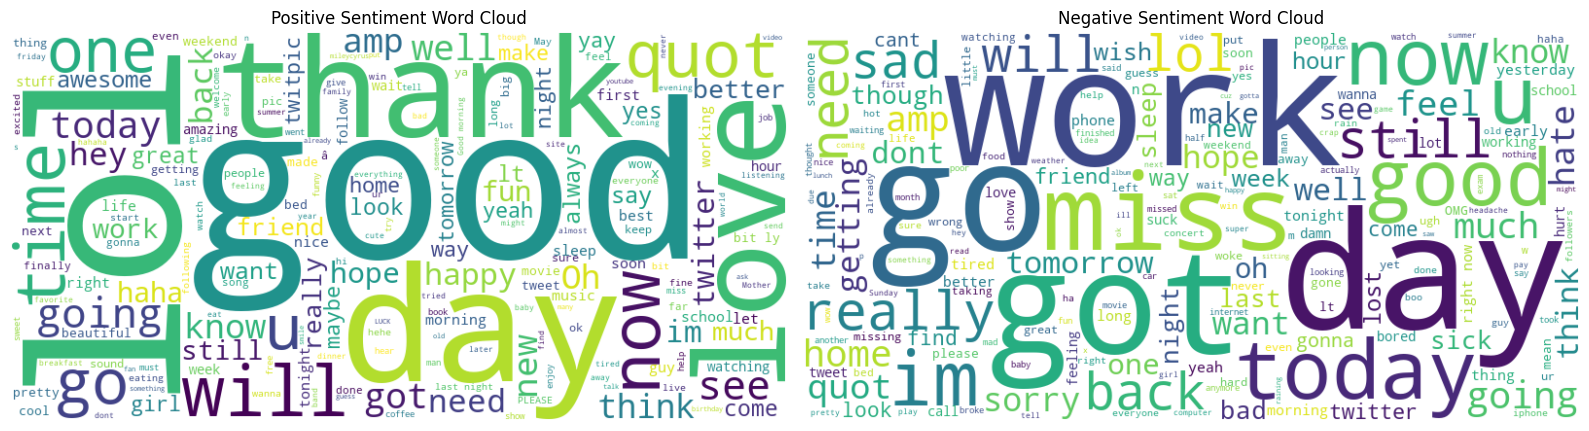

In [ ]:
# 12. Visualize word clouds in one plot

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(positive_wordcloud, interpolation="bilinear")
axes[0].set_title("Positive Sentiment Word Cloud")
axes[0].axis("off")

axes[1].imshow(negative_wordcloud, interpolation="bilinear")
axes[1].set_title("Negative Sentiment Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 13. Save word cloud plot

# 13. Save word cloud plot

import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(positive_wordcloud, interpolation="bilinear")
axes[0].set_title("Positive Sentiment Word Cloud")
axes[0].axis("off")

axes[1].imshow(negative_wordcloud, interpolation="bilinear")
axes[1].set_title("Negative Sentiment Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(WORDCLOUD_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Word cloud image saved to: {WORDCLOUD_OUTPUT_PATH}")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(positive_wordcloud, interpolation="bilinear")
axes[0].set_title("Positive Sentiment Word Cloud")
axes[0].axis("off")

axes[1].imshow(negative_wordcloud, interpolation="bilinear")
axes[1].set_title("Negative Sentiment Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(WORDCLOUD_OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Word cloud image saved to: {WORDCLOUD_OUTPUT_PATH}")

AttributeError: 'str' object has no attribute 'mkdir'